# import libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import Counter
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.layers import (
    Layer,
    LayerNormalization,
    Dense,
    Input
)
from tensorflow.keras.optimizers import AdamW

In [2]:

df = pd.read_csv("qm8.csv")
# Generate 3D coordinates from SMILES

def smiles_to_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)
    status = AllChem.EmbedMolecule(mol, randomSeed=42)

    if status != 0:
        return None

    if mol.GetNumConformers() == 0:
        return None

    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        return None

    conf = mol.GetConformer()

    molecule = []
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        atom_type = atom.GetSymbol()
        coordinates = np.array([pos.x, pos.y, pos.z], dtype=float)
        molecule.append((atom_type, coordinates))

    return molecule

In [3]:
with open("qm8_processed.pkl", "rb") as f:
    data = pickle.load(f)

mollist = data["mollist"]
Y = data["Y"]
valid_indices = data["valid_indices"]

In [4]:
# Get weights and views for QM8 dataset
import qm8_weighted_views as CP
from qm8_weighted_views import load_qm8_data
def speciesmap(atom_type):
    atom_to_number = {'H': 1, 'C': 6, 'N': 7, 'O': 8, 'S': 16, 'F': 9}
    #print(atom_type)
    return np.array([atom_to_number.get(atom_type, 0)])  # Returns 0 if atom type is not recognized
ws, vs, Natoms, Nviews = load_qm8_data(mollist, setNviews=None, carbonbased=False, splitx= True, verbose=0)

colinear 6.322027276634106e-08
colinear 5.771194914292421e-08
colinear 5.960464477539064e-08
colinear 7.45058059692383e-08
colinear 7.146345858741881e-08
colinear 5.575503985246929e-08
colinear 3.1415925629495685
colinear 3.141592569296096
colinear 3.1415926202697837
colinear 3.1415926325163688
colinear 2.9802322387695312e-08
colinear 2.1073424255447017e-08
colinear 9.65705618025044e-08
colinear 4.942156062059701e-08
colinear 4.2146848510894035e-08
colinear 9.305772182939053e-08
colinear 4.712160915387242e-08
colinear 7.300048299977716e-08
colinear 4.4703483581542975e-08
colinear 6.495265578539184e-08
colinear 4.712160915387242e-08
colinear 2.1073424255447017e-08
structuretoviews: WARNING: cosofangle >= 1: 1.0000000000000002
colinear 0.0
colinear 4.942156062059701e-08
colinear 3.141592559346575
colinear 3.1415925581758066
colinear 3.6500241499888574e-08
colinear 3.942476676500724e-08
colinear 7.598131170262078e-08
colinear 3.1415925886371374
colinear 3.1415925679891394
colinear 9.65705

In [5]:
print(ws.shape) # we were suppossed to have 26 views but we have 52 which is twice and then (26*5 = 130)
print(vs.shape)

(21645, 52)
(21645, 52, 130)


In [6]:
from sklearn.model_selection import train_test_split

X = mollist   # list of 21645 molecules
y = Y         # shape (21645, 12)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(X_train), len(X_test))
print(y_train.shape, y_test.shape)

17316 4329
(17316, 12) (4329, 12)


In [7]:
qm8_train = X_train
qm8_test = X_test
qm8_labels_train = y_train
qm8_labels_test = y_test

In [8]:
ws_qm8_train, vs_qm8_train, Natoms_train, Nviews_train = load_qm8_data(qm8_train, setNviews=None, carbonbased=False, splitx= True, verbose=0)
qm8G_train=[ws_qm8_train, vs_qm8_train]
ws_qm8_test, vs_qm8_test, Natoms_test, Nviews_test = load_qm8_data(qm8_test, setNviews=None, carbonbased=False, splitx= True, verbose=0)
qm8G_test=[ws_qm8_test, vs_qm8_test]

colinear 3.1415925629495685
colinear 3.141592569296096
colinear 3.1415926202697837
colinear 3.1415926325163688
colinear 2.9802322387695312e-08
colinear 2.1073424255447017e-08
colinear 9.65705618025044e-08
colinear 4.942156062059701e-08
colinear 4.2146848510894035e-08
colinear 9.305772182939053e-08
colinear 3.1415925733445844
colinear 3.1415925747402595
colinear 8.296615425989067e-08
colinear 3.942476676500724e-08
colinear 9.541398640621977e-08
colinear 3.942476676500724e-08
colinear 6.143906154658886e-08
colinear 2.9802322387695312e-08
colinear 6.143906154658886e-08
colinear 2.580956827951785e-08
colinear 4.2146848510894035e-08
colinear 3.141592611442945
colinear 3.1415925654333345
colinear 3.1415926064681843
colinear 5.16191365590357e-08
colinear 3.1415925617328666
colinear 3.141592559346575
structuretoviews: WARNING: cosofangle >= 1: 1.0
colinear 0.0
colinear 3.1415926202697837
colinear 3.141592579083987
colinear 3.1415926202697837
colinear 4.4703483581542975e-08
colinear 9.996002811

In [9]:
print(ws_qm8_train.shape)
print(vs_qm8_train.shape)
print(ws_qm8_test.shape)
print(vs_qm8_test.shape)

(17316, 52)
(17316, 52, 130)
(4329, 52)
(4329, 52, 130)


# Find Broken views

In [9]:

from qm8_additional import small_views
single_atom_qm8_train = small_views(vs_qm8_train)
single_atom_qm8_test = small_views(vs_qm8_test)
print(single_atom_qm8_train.shape)
print(single_atom_qm8_test.shape)

(17316, 52, 26, 5)
(4329, 52, 26, 5)


# Add single atom properties

In [10]:
from qm8_additional import atom_properties, single_atomic_property_switches, get_embeddings
atom_embeddings_qm8_train = get_embeddings(single_atom_qm8_train, atom_properties, single_atomic_property_switches)
atom_embeddings_qm8_test  = get_embeddings(single_atom_qm8_test,  atom_properties, single_atomic_property_switches)

In [12]:
print(atom_embeddings_qm8_train.shape)
print(atom_embeddings_qm8_test.shape)
print(atom_embeddings_qm8_train.dtype)
print(atom_embeddings_qm8_test.dtype)

(17316, 52, 26, 13)
(4329, 52, 26, 13)
float64
float64


In [11]:

Xtr = atom_embeddings_qm8_train.copy()  
Xte = atom_embeddings_qm8_test.copy()   

mask_tr = (Xtr[..., 0] != 0)   
mask_te = (Xte[..., 0] != 0)


props_tr = Xtr[..., 5:13][mask_tr]   
prop_scaler = StandardScaler().fit(props_tr)


Xtr[..., 5:13][mask_tr] = prop_scaler.transform(Xtr[..., 5:13][mask_tr])
Xte[..., 5:13][mask_te] = prop_scaler.transform(Xte[..., 5:13][mask_te])

In [14]:
labelsG_train = qm8_labels_train
labelsG_test = qm8_labels_test
Ntoxicity = 3
ws_train, vs_train = ws_qm8_train, Xtr
ws_test, vs_test = ws_qm8_test, Xte
dataG_train=[ws_train,vs_train]
dataG_test=[ws_test,vs_test]
print(type(labelsG_train))
print(type(labelsG_test))
print(ws_train.shape)
print(vs_train.shape)
print(ws_test.shape)
print(vs_test.shape)
print(labelsG_train.shape)
print(labelsG_test.shape)
print(len(dataG_train))
print(len(dataG_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(17316, 52)
(17316, 52, 26, 13)
(4329, 52)
(4329, 52, 26, 13)
(17316, 12)
(4329, 12)
2
2


# Transformer Layer with ceneter based Attention

In [15]:

class AtomAttentionWithGlobalToken(Layer):

    def __init__(self, d_k=32, d_v=16, **kwargs):

        super(AtomAttentionWithGlobalToken, self).__init__(**kwargs)

        self.d_k = d_k
        self.d_v = d_v

        self.norm = LayerNormalization(
            axis=-1,
            epsilon=1e-6
        )

    def build(self, input_shape):

        # input shape:
        # (batch, views, atoms, features)

        self.num_views = input_shape[1]
        self.num_atoms = input_shape[2]
        self.feature_dim = input_shape[3]

        # --------------------------------------------------
        # Q projection
        # --------------------------------------------------

        self.W_q = self.add_weight(
            name='W_q',
            shape=(self.feature_dim, self.d_k),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # K projection
        # --------------------------------------------------

        self.W_k = self.add_weight(
            name='W_k',
            shape=(self.feature_dim, self.d_k),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # V projection
        # --------------------------------------------------

        self.W_v = self.add_weight(
            name='W_v',
            shape=(self.feature_dim, self.d_v),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # Output projection
        # --------------------------------------------------

        self.W_o = self.add_weight(
            name='W_o',
            shape=(self.d_v, self.feature_dim),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # Learnable global token
        # --------------------------------------------------

        self.global_token = self.add_weight(
            name='global_token',
            shape=(1, 1, 1, self.feature_dim),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AtomAttentionWithGlobalToken, self).build(input_shape)

    def _build_padding_mask(self, reshaped_input):

        token_is_padding = tf.reduce_all(
            tf.equal(reshaped_input, 0.0),
            axis=-1
        )

        # token 0 = global token

        batch_view_size = tf.shape(token_is_padding)[0]

        global_not_padding = tf.zeros(
            (batch_view_size, 1),
            dtype=tf.bool
        )

        atom_padding = token_is_padding[:, 1:]

        token_is_padding = tf.concat(
            [global_not_padding, atom_padding],
            axis=1
        )

        pairwise_mask = tf.logical_or(
            tf.expand_dims(token_is_padding, axis=2),
            tf.expand_dims(token_is_padding, axis=1)
        )

        return pairwise_mask

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]

        # --------------------------------------------------
        # Add global token
        # --------------------------------------------------

        if inputs.shape[2] == self.num_atoms:

            global_token = tf.tile(
                self.global_token,
                [batch_size, self.num_views, 1, 1]
            )

            x = tf.concat(
                [global_token, inputs],
                axis=2
            )

        else:

            x = inputs

        total_tokens = x.shape[2]

        # --------------------------------------------------
        # Combine batch and views
        # --------------------------------------------------

        reshaped_input = tf.reshape(
            x,
            [-1, total_tokens, self.feature_dim]
        )

        # --------------------------------------------------
        # Q K V
        # --------------------------------------------------

        Q = tf.matmul(
            reshaped_input,
            self.W_q
        )

        K = tf.matmul(
            reshaped_input,
            self.W_k
        )

        V = tf.matmul(
            reshaped_input,
            self.W_v
        )

        # --------------------------------------------------
        # Attention scores
        # --------------------------------------------------

        scale = tf.math.sqrt(
            tf.cast(self.d_k, tf.float32)
        )

        scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        ) / scale

        # --------------------------------------------------
        # Padding mask
        # --------------------------------------------------

        pairwise_mask = self._build_padding_mask(
            reshaped_input
        )

        neg_inf = tf.constant(
            -1e9,
            dtype=scores.dtype
        )

        scores = tf.where(
            pairwise_mask,
            neg_inf,
            scores
        )

        # --------------------------------------------------
        # Softmax
        # --------------------------------------------------

        attn = tf.nn.softmax(
            scores,
            axis=-1
        )

        # --------------------------------------------------
        # Attention output
        # --------------------------------------------------

        output = tf.matmul(
            attn,
            V
        )

        # --------------------------------------------------
        # Project back
        # --------------------------------------------------

        output = tf.matmul(
            output,
            self.W_o
        )

        # --------------------------------------------------
        # Residual + LayerNorm
        # --------------------------------------------------

        output = self.norm(
            reshaped_input + output
        )

        # --------------------------------------------------
        # Reshape back
        # --------------------------------------------------

        output = tf.reshape(
            output,
            [
                batch_size,
                self.num_views,
                total_tokens,
                self.feature_dim
            ]
        )

        return output


class FeedForward(Layer):

    def __init__(self,
                 d_model=13,
                 d_ff=64,
                 **kwargs):

        super(FeedForward, self).__init__(**kwargs)

        self.fc1 = Dense(
            d_ff,
            activation='relu'
        )

        self.fc2 = Dense(
            d_model
        )

        self.norm = LayerNormalization(
            axis=-1,
            epsilon=1e-6
        )

    def call(self, x):

        y = self.fc1(x)

        y = self.fc2(y)

        return self.norm(x + y)


class TransformerBlockWithGlobalToken(Layer):

    def __init__(self,
                 d_model=13,
                 d_k=32,
                 d_v=16,
                 d_ff=64,
                 **kwargs):

        super(TransformerBlockWithGlobalToken, self).__init__(**kwargs)

        self.attn = AtomAttentionWithGlobalToken(
            d_k=d_k,
            d_v=d_v
        )

        self.ffn = FeedForward(
            d_model=d_model,
            d_ff=d_ff
        )

    def call(self, x):

        x = self.attn(x)

        x = self.ffn(x)

        return x

In [16]:
# generic dense NN
def multiDense(Nin,Nout,Nhidden,widthhidden=None,kernel_regularizer=None):
    """Construct a basic NN with some dense layers.
    
    :parameter Nin: The number of inputs
    :type Nin: int
    :parameter Nout: The number of outputs
    :type Nout: int
    :parameter Nhidden: The number of hidden layers.
    :type Nhidden: int
    :parameter widthhidden: The width of each hidden layer.
        If left at None, Nin + Nout will be used.
    :parameter kernel_regularizer: the regularizer to use, such as regularizers.l2(0.001)
    :type kernel_regularizer: tensorflow.keras.regularizers.xxx
    :returns: The NN model
    :rtype: keras.Model
    
    """
    if widthhidden is None:
        widthhidden = Nin + Nout
    x = inputs = keras.Input(shape=(Nin,), name='multiDense_input')
    if kernel_regularizer is not None:
        print("Using regularization")
    for i in range(Nhidden):
        x = layers.Dense(widthhidden, activation='relu', kernel_regularizer=kernel_regularizer,name='dense'+str(i))(x)
    outputs = layers.Dense(Nout,name='multiDense_output')(x)
    #outputs = tf.nn.leaky_relu(outputs, alpha=0.05)
    return keras.Model(inputs=inputs, outputs=outputs)#, name='multiDense')
def parallelwrapper(Nparallel,basemodel,insteadmax=False):
    """Construct a model that applies a basemodel multiple times and take a weighted sum (or max) of the result.
    
    :parameter Nparallel: The number of times to apply in parallel
    :type Nparallel: int
    :parameter basemodel: a keras.Model inferred to have Nin inputs and Nout outputs.
    :type basemodel: a keras.Model
    :parameter insteadmax: If True, take the max of the results of the basemodel instead of the weighted sum.
        For compatibility, the model is still constructed with weights as inputs, but it ignores them.
    :type insteadmax: Boolean
    :returns: model with inputs shape [(?,Nparallel),(?,Nin,Nparallel)] and outputs shape (?,Nout).
        The first input is the scalar weights in the sum.
    :rtype: keras.Model
    
    Note: We could do a max over the parallel applications instead of or in addition to the weighted sum.
    
    """
    # infer shape of basemodel inputs and outputs
    Nin =  basemodel.inputs[0].shape[1]
    Nout =  basemodel.outputs[0].shape[1]
    parallel_inputs = keras.Input(shape=(Nparallel,Nin), name='parallelwrapper_input0')
    # apply base NN to each parallel slice; outputs (?,Nparallel,Nout)
    if False:
        # original version, stopped working at some tensorflow update
        xb = basemodel(parallel_inputs) # worked in earlier tensorflow
        #xb = tf.map_fn(basemodel,parallel_inputs) # another version that fails
    else:
        parallel_inputsunstacked = tf.keras.ops.unstack(parallel_inputs, Nparallel, 1)
        # apply base NN to each 
        xbunstacked = [basemodel(x) for x in parallel_inputsunstacked]
        # re-stack
        xb = tf.keras.ops.stack(xbunstacked,axis=1)
    
    # create input scalars for weighted sun (?,Nparallel)
    weight_inputs = keras.Input(shape=(Nparallel,), name='parallelScalars')
    if insteadmax:
        # take max over the Nparallel direction to get (?,1,Nout)
        out = layers.MaxPool1D(pool_size=Nparallel)(xb)
        # reshape to (?,Nout)
        out = layers.Reshape((Nout,))(out)
    else:
        # do a weighted sum over the Nparallel direction to get (?,Nout)
        out = layers.Dot((-2,-1))([xb,weight_inputs])
    
    return keras.Model(inputs=[weight_inputs,parallel_inputs], outputs=out, name='parallelwrapper')


In [17]:

def init_generator(data, labels,
                   baselayers, Nfeatures, endlayers,
                   base_regularizer=None, end_regularizer=None,
                   num_blocks=3, d_ff=64):


    Nviews  = data[0].shape[1]
    Natoms  = data[1].shape[2]
    d_model = data[1].shape[3]

    weight_input = Input(
        (Nviews,),
        name='weight_input'
    )

    atom_input = Input(
        (Nviews, Natoms, d_model),
        name='atom_input'
    )

    x = atom_input

    for i in range(num_blocks):

        x = TransformerBlockWithGlobalToken(
            d_model=d_model,
            d_k=32,
            d_v=d_model,
            d_ff=d_ff,
            name=f'transformer_block_{i}'
        )(x)


    x = x[:, :, 0, :]


    Gbase = multiDense(
        d_model,
        Nfeatures,
        baselayers,
        kernel_regularizer=base_regularizer
    )

    Gpw = parallelwrapper(
        Nviews,
        Gbase,
        insteadmax=False
    )

    x = Gpw([weight_input, x])


    Gft = multiDense(
        Nfeatures,
        12,
        endlayers,
        kernel_regularizer=end_regularizer
    )

    output = Gft(x)

    

    generator = Model(
        [weight_input, atom_input],
        output,
        name='generator_with_global_token'
    )

    generator.compile(
        optimizer=AdamW(learning_rate=0.002),
        loss='mae',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae')
        ]
    )

    return generator
# Hyperparameters
baselayers = 3
base_reg = 0
Nfeatures = 12
endlayers = 2
end_reg = 0

base_regularizer = regularizers.l2(base_reg) if base_reg else None
end_regularizer = regularizers.l2(end_reg) if end_reg else None

generator = init_generator(
    dataG_train,
    labelsG_train,
    baselayers,
    Nfeatures,
    endlayers,
    base_regularizer=base_regularizer,
    end_regularizer=end_regularizer
)

In [18]:
%%time

BATCH_SIZE = 32

#early_stop = EarlyStopping(
#    monitor='val_loss',
#    patience=7,
#    restore_best_weights=True,
#    verbose=1
#)

history = generator.fit(
    dataG_train,
    labelsG_train,
    epochs=200,
    batch_size=BATCH_SIZE,
    validation_data=(dataG_test, labelsG_test),
    #callbacks=[early_stop],
    verbose=1
)

print(
    "train loss =",
    generator.evaluate(
        dataG_train,
        labelsG_train,
        verbose=1
    )
)

print(
    "test loss =",
    generator.evaluate(
        dataG_test,
        labelsG_test,
        verbose=1
    )
)

Epoch 1/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - loss: 0.0429 - mae: 0.0429 - val_loss: 0.0277 - val_mae: 0.0277
Epoch 2/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - loss: 0.0268 - mae: 0.0268 - val_loss: 0.0263 - val_mae: 0.0263
Epoch 3/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - loss: 0.0263 - mae: 0.0263 - val_loss: 0.0261 - val_mae: 0.0261
Epoch 4/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.0257 - mae: 0.0257 - val_loss: 0.0251 - val_mae: 0.0251
Epoch 5/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.0245 - mae: 0.0245 - val_loss: 0.0228 - val_mae: 0.0228
Epoch 6/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.0234 - mae: 0.0234 - val_loss: 0.0225 - val_mae: 0.0225
Epoch 7/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - loss: 0.0227 - mae: 0.0227 - val_loss: 0.0221 - val_mae: 0.0221
Epoch 8/200
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.0220 - mae: 0.0220 - val_loss: 0.0235 - val_mae: 0.0235
Epoch 9/200
542/542 ━━━━━━━━━━━━

In [19]:
property_names = [
    "E1-CC2",
    "E2-CC2",
    "f1-CC2",
    "f2-CC2",
    "E1-PBE0",
    "E2-PBE0",
    "f1-PBE0",
    "f2-PBE0",
    "E1-CAM",
    "E2-CAM",
    "f1-CAM",
    "f2-CAM"
]

y_pred = generator.predict(dataG_test)

overall_mae = np.mean(
    np.abs(labelsG_test - y_pred)
)

print("\nOverall MAE:", overall_mae)

mae_per_property = np.mean(
    np.abs(labelsG_test - y_pred),
    axis=0
)

print("\nMAE per property:\n")

for name, mae in zip(property_names, mae_per_property):

    print(f"{name:10s} : {mae:.6f}")


average_task_mae = np.mean(mae_per_property)

print("\nAverage task MAE:", average_task_mae)

136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step

Overall MAE: 0.0148740973052182

MAE per property:

E1-CC2     : 0.008433
E2-CC2     : 0.009609
f1-CC2     : 0.014406
f2-CC2     : 0.032497
E1-PBE0    : 0.008644
E2-PBE0    : 0.009519
f1-PBE0    : 0.012388
f2-PBE0    : 0.025230
E1-CAM     : 0.007724
E2-CAM     : 0.009242
f1-CAM     : 0.013688
f2-CAM     : 0.027107

Average task MAE: 0.014874097305218192


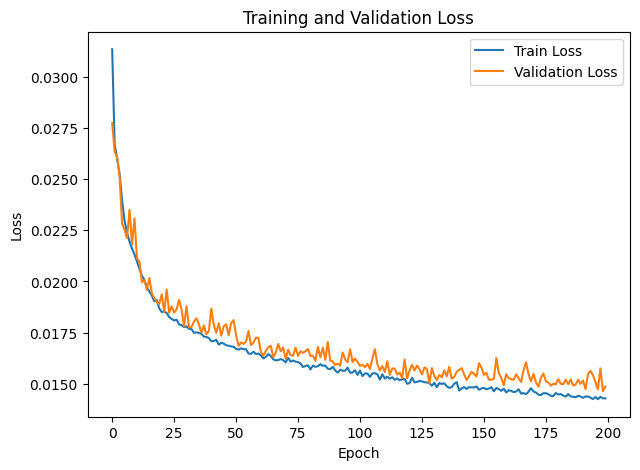

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
y_pred shape: (4329, 12)
labelsG_test shape: (4329, 12)


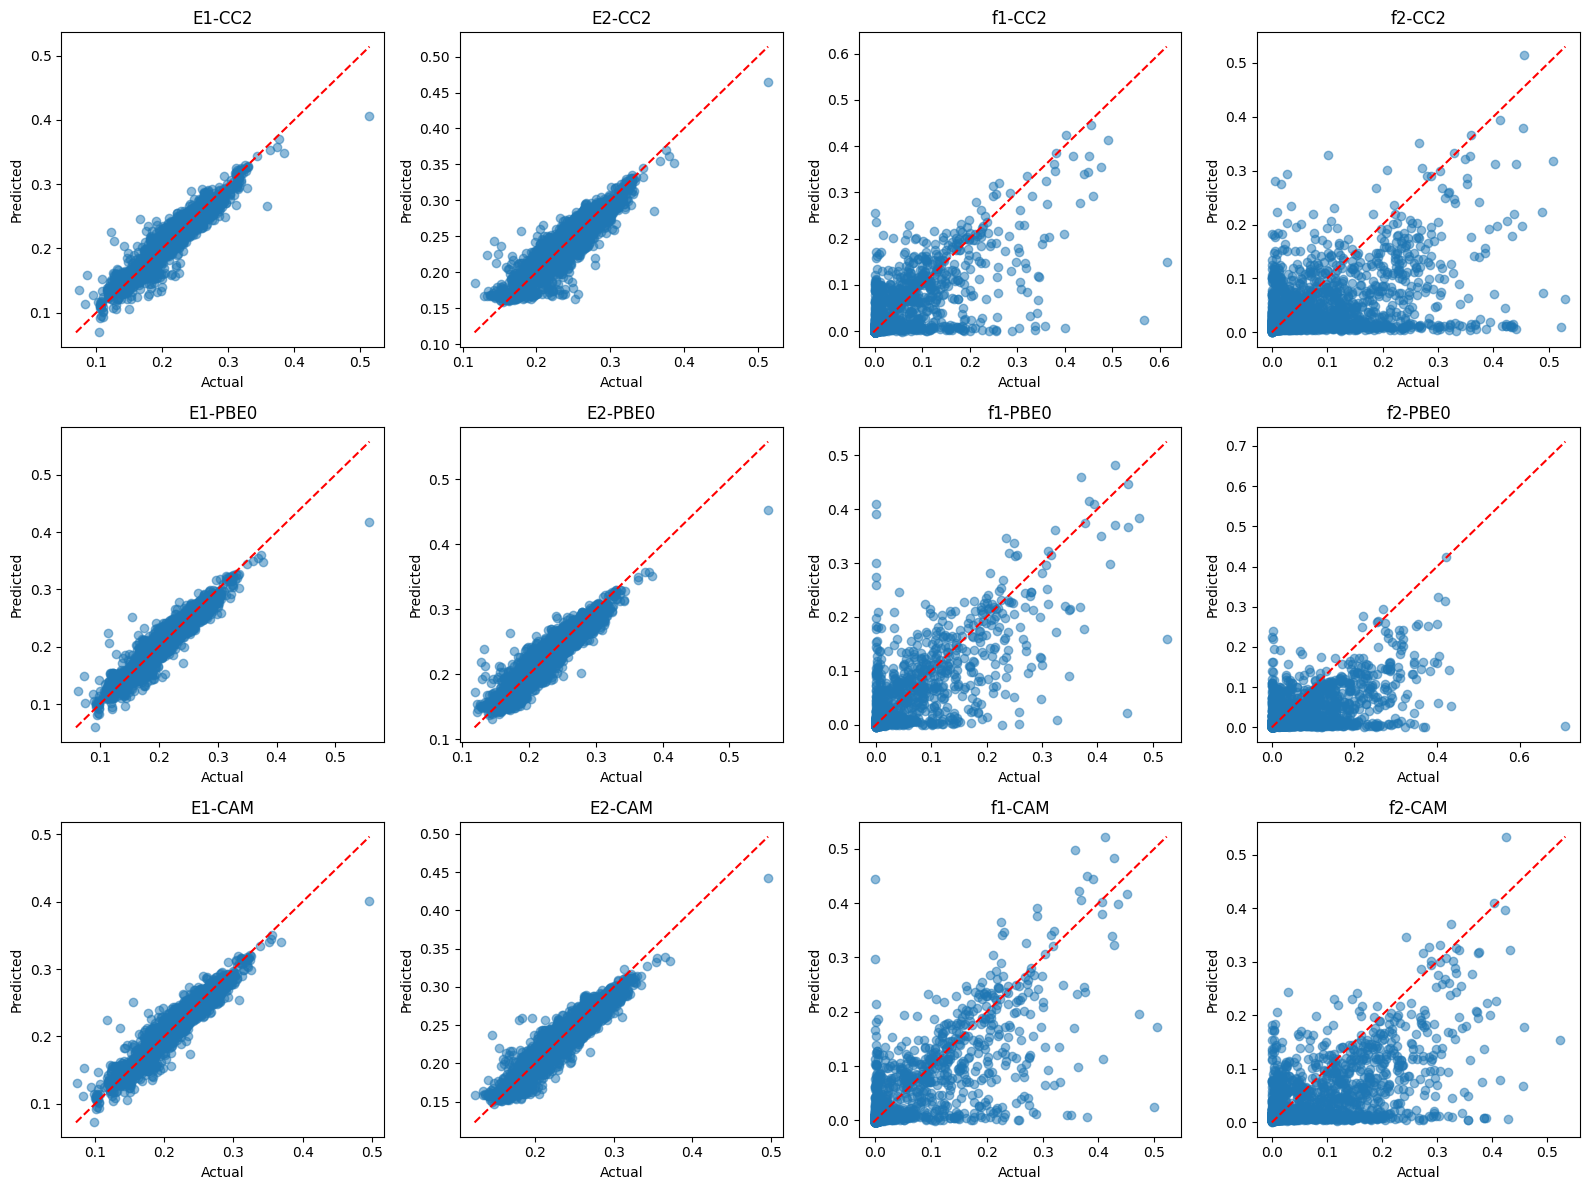

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Predict on test set
y_pred = generator.predict(dataG_test)

# Make sure shapes are correct
print("y_pred shape:", y_pred.shape)         # should be (4329, 12)
print("labelsG_test shape:", labelsG_test.shape)   # should be (4329, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    y_true_i = labelsG_test[:, i]
    y_pred_i = y_pred[:, i]
    
    axes[i].scatter(y_true_i, y_pred_i, alpha=0.5)
    
    # diagonal reference line
    min_val = min(y_true_i.min(), y_pred_i.min())
    max_val = max(y_true_i.max(), y_pred_i.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--')
    
    axes[i].set_title(property_names[i])
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# performance on standridzation

In [12]:
labelsG_train = qm8_labels_train
labelsG_test = qm8_labels_test
Ntoxicity = 3
ws_train, vs_train = ws_qm8_train, Xtr
ws_test, vs_test = ws_qm8_test, Xte
dataG_train=[ws_train,vs_train]
dataG_test=[ws_test,vs_test]
print(type(labelsG_train))
print(type(labelsG_test))
print(ws_train.shape)
print(vs_train.shape)
print(ws_test.shape)
print(vs_test.shape)
print(labelsG_train.shape)
print(labelsG_test.shape)
print(len(dataG_train))
print(len(dataG_test))


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(17316, 52)
(17316, 52, 26, 13)
(4329, 52)
(4329, 52, 26, 13)
(17316, 12)
(4329, 12)
2
2


In [13]:
mu = labelsG_train.mean(axis=0)
sigma = labelsG_train.std(axis=0)

labelsG_train = (labelsG_train - mu) / sigma
labelsG_test  = (labelsG_test  - mu) / sigma

In [14]:

class AtomAttentionWithGlobalToken(Layer):

    def __init__(self, d_k=32, d_v=16, **kwargs):

        super(AtomAttentionWithGlobalToken, self).__init__(**kwargs)

        self.d_k = d_k
        self.d_v = d_v

        self.norm = LayerNormalization(
            axis=-1,
            epsilon=1e-6
        )

    def build(self, input_shape):

        # input shape:
        # (batch, views, atoms, features)

        self.num_views = input_shape[1]
        self.num_atoms = input_shape[2]
        self.feature_dim = input_shape[3]

        # --------------------------------------------------
        # Q projection
        # --------------------------------------------------

        self.W_q = self.add_weight(
            name='W_q',
            shape=(self.feature_dim, self.d_k),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # K projection
        # --------------------------------------------------

        self.W_k = self.add_weight(
            name='W_k',
            shape=(self.feature_dim, self.d_k),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # V projection
        # --------------------------------------------------

        self.W_v = self.add_weight(
            name='W_v',
            shape=(self.feature_dim, self.d_v),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # Output projection
        # --------------------------------------------------

        self.W_o = self.add_weight(
            name='W_o',
            shape=(self.d_v, self.feature_dim),
            initializer='glorot_uniform',
            trainable=True
        )

        # --------------------------------------------------
        # Learnable global token
        # --------------------------------------------------

        self.global_token = self.add_weight(
            name='global_token',
            shape=(1, 1, 1, self.feature_dim),
            initializer='glorot_uniform',
            trainable=True
        )

        super(AtomAttentionWithGlobalToken, self).build(input_shape)

    def _build_padding_mask(self, reshaped_input):

        token_is_padding = tf.reduce_all(
            tf.equal(reshaped_input, 0.0),
            axis=-1
        )

        # token 0 = global token

        batch_view_size = tf.shape(token_is_padding)[0]

        global_not_padding = tf.zeros(
            (batch_view_size, 1),
            dtype=tf.bool
        )

        atom_padding = token_is_padding[:, 1:]

        token_is_padding = tf.concat(
            [global_not_padding, atom_padding],
            axis=1
        )

        pairwise_mask = tf.logical_or(
            tf.expand_dims(token_is_padding, axis=2),
            tf.expand_dims(token_is_padding, axis=1)
        )

        return pairwise_mask

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]

        # --------------------------------------------------
        # Add global token
        # --------------------------------------------------

        if inputs.shape[2] == self.num_atoms:

            global_token = tf.tile(
                self.global_token,
                [batch_size, self.num_views, 1, 1]
            )

            x = tf.concat(
                [global_token, inputs],
                axis=2
            )

        else:

            x = inputs

        total_tokens = x.shape[2]

        # --------------------------------------------------
        # Combine batch and views
        # --------------------------------------------------

        reshaped_input = tf.reshape(
            x,
            [-1, total_tokens, self.feature_dim]
        )

        # --------------------------------------------------
        # Q K V
        # --------------------------------------------------

        Q = tf.matmul(
            reshaped_input,
            self.W_q
        )

        K = tf.matmul(
            reshaped_input,
            self.W_k
        )

        V = tf.matmul(
            reshaped_input,
            self.W_v
        )

        # --------------------------------------------------
        # Attention scores
        # --------------------------------------------------

        scale = tf.math.sqrt(
            tf.cast(self.d_k, tf.float32)
        )

        scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        ) / scale

        # --------------------------------------------------
        # Padding mask
        # --------------------------------------------------

        pairwise_mask = self._build_padding_mask(
            reshaped_input
        )

        neg_inf = tf.constant(
            -1e9,
            dtype=scores.dtype
        )

        scores = tf.where(
            pairwise_mask,
            neg_inf,
            scores
        )

        # --------------------------------------------------
        # Softmax
        # --------------------------------------------------

        attn = tf.nn.softmax(
            scores,
            axis=-1
        )

        # --------------------------------------------------
        # Attention output
        # --------------------------------------------------

        output = tf.matmul(
            attn,
            V
        )

        # --------------------------------------------------
        # Project back
        # --------------------------------------------------

        output = tf.matmul(
            output,
            self.W_o
        )

        # --------------------------------------------------
        # Residual + LayerNorm
        # --------------------------------------------------

        output = self.norm(
            reshaped_input + output
        )

        # --------------------------------------------------
        # Reshape back
        # --------------------------------------------------

        output = tf.reshape(
            output,
            [
                batch_size,
                self.num_views,
                total_tokens,
                self.feature_dim
            ]
        )

        return output


class FeedForward(Layer):

    def __init__(self,
                 d_model=13,
                 d_ff=64,
                 **kwargs):

        super(FeedForward, self).__init__(**kwargs)

        self.fc1 = Dense(
            d_ff,
            activation='relu'
        )

        self.fc2 = Dense(
            d_model
        )

        self.norm = LayerNormalization(
            axis=-1,
            epsilon=1e-6
        )

    def call(self, x):

        y = self.fc1(x)

        y = self.fc2(y)

        return self.norm(x + y)


class TransformerBlockWithGlobalToken(Layer):

    def __init__(self,
                 d_model=13,
                 d_k=32,
                 d_v=16,
                 d_ff=64,
                 **kwargs):

        super(TransformerBlockWithGlobalToken, self).__init__(**kwargs)

        self.attn = AtomAttentionWithGlobalToken(
            d_k=d_k,
            d_v=d_v
        )

        self.ffn = FeedForward(
            d_model=d_model,
            d_ff=d_ff
        )

    def call(self, x):

        x = self.attn(x)

        x = self.ffn(x)

        return x

In [16]:
# generic dense NN
def multiDense(Nin,Nout,Nhidden,widthhidden=None,kernel_regularizer=None):
    """Construct a basic NN with some dense layers.
    
    :parameter Nin: The number of inputs
    :type Nin: int
    :parameter Nout: The number of outputs
    :type Nout: int
    :parameter Nhidden: The number of hidden layers.
    :type Nhidden: int
    :parameter widthhidden: The width of each hidden layer.
        If left at None, Nin + Nout will be used.
    :parameter kernel_regularizer: the regularizer to use, such as regularizers.l2(0.001)
    :type kernel_regularizer: tensorflow.keras.regularizers.xxx
    :returns: The NN model
    :rtype: keras.Model
    
    """
    if widthhidden is None:
        widthhidden = Nin + Nout
    x = inputs = keras.Input(shape=(Nin,), name='multiDense_input')
    if kernel_regularizer is not None:
        print("Using regularization")
    for i in range(Nhidden):
        x = layers.Dense(widthhidden, activation='relu', kernel_regularizer=kernel_regularizer,name='dense'+str(i))(x)
    outputs = layers.Dense(Nout,name='multiDense_output')(x)
    #outputs = tf.nn.leaky_relu(outputs, alpha=0.05)
    return keras.Model(inputs=inputs, outputs=outputs)#, name='multiDense')
def parallelwrapper(Nparallel,basemodel,insteadmax=False):
    """Construct a model that applies a basemodel multiple times and take a weighted sum (or max) of the result.
    
    :parameter Nparallel: The number of times to apply in parallel
    :type Nparallel: int
    :parameter basemodel: a keras.Model inferred to have Nin inputs and Nout outputs.
    :type basemodel: a keras.Model
    :parameter insteadmax: If True, take the max of the results of the basemodel instead of the weighted sum.
        For compatibility, the model is still constructed with weights as inputs, but it ignores them.
    :type insteadmax: Boolean
    :returns: model with inputs shape [(?,Nparallel),(?,Nin,Nparallel)] and outputs shape (?,Nout).
        The first input is the scalar weights in the sum.
    :rtype: keras.Model
    
    Note: We could do a max over the parallel applications instead of or in addition to the weighted sum.
    
    """
    # infer shape of basemodel inputs and outputs
    Nin =  basemodel.inputs[0].shape[1]
    Nout =  basemodel.outputs[0].shape[1]
    parallel_inputs = keras.Input(shape=(Nparallel,Nin), name='parallelwrapper_input0')
    # apply base NN to each parallel slice; outputs (?,Nparallel,Nout)
    if False:
        # original version, stopped working at some tensorflow update
        xb = basemodel(parallel_inputs) # worked in earlier tensorflow
        #xb = tf.map_fn(basemodel,parallel_inputs) # another version that fails
    else:
        parallel_inputsunstacked = tf.keras.ops.unstack(parallel_inputs, Nparallel, 1)
        # apply base NN to each 
        xbunstacked = [basemodel(x) for x in parallel_inputsunstacked]
        # re-stack
        xb = tf.keras.ops.stack(xbunstacked,axis=1)
    
    # create input scalars for weighted sun (?,Nparallel)
    weight_inputs = keras.Input(shape=(Nparallel,), name='parallelScalars')
    if insteadmax:
        # take max over the Nparallel direction to get (?,1,Nout)
        out = layers.MaxPool1D(pool_size=Nparallel)(xb)
        # reshape to (?,Nout)
        out = layers.Reshape((Nout,))(out)
    else:
        # do a weighted sum over the Nparallel direction to get (?,Nout)
        out = layers.Dot((-2,-1))([xb,weight_inputs])
    
    return keras.Model(inputs=[weight_inputs,parallel_inputs], outputs=out, name='parallelwrapper')


In [17]:

def init_generator(data, labels,
                   baselayers, Nfeatures, endlayers,
                   base_regularizer=None, end_regularizer=None,
                   num_blocks=3, d_ff=64):


    Nviews  = data[0].shape[1]
    Natoms  = data[1].shape[2]
    d_model = data[1].shape[3]

    weight_input = Input(
        (Nviews,),
        name='weight_input'
    )

    atom_input = Input(
        (Nviews, Natoms, d_model),
        name='atom_input'
    )

    x = atom_input

    for i in range(num_blocks):

        x = TransformerBlockWithGlobalToken(
            d_model=d_model,
            d_k=32,
            d_v=d_model,
            d_ff=d_ff,
            name=f'transformer_block_{i}'
        )(x)


    x = x[:, :, 0, :]


    Gbase = multiDense(
        d_model,
        Nfeatures,
        baselayers,
        kernel_regularizer=base_regularizer
    )

    Gpw = parallelwrapper(
        Nviews,
        Gbase,
        insteadmax=False
    )

    x = Gpw([weight_input, x])


    Gft = multiDense(
        Nfeatures,
        12,
        endlayers,
        kernel_regularizer=end_regularizer
    )

    output = Gft(x)

    

    generator = Model(
        [weight_input, atom_input],
        output,
        name='generator_with_global_token'
    )

    generator.compile(
        optimizer=AdamW(learning_rate=0.002),
        loss='mae',
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name='mae')
        ]
    )

    return generator
# Hyperparameters
baselayers = 3
base_reg = 0
Nfeatures = 12
endlayers = 2
end_reg = 0

base_regularizer = regularizers.l2(base_reg) if base_reg else None
end_regularizer = regularizers.l2(end_reg) if end_reg else None

generator = init_generator(
    dataG_train,
    labelsG_train,
    baselayers,
    Nfeatures,
    endlayers,
    base_regularizer=base_regularizer,
    end_regularizer=end_regularizer
)

In [19]:
%%time

BATCH_SIZE = 32

#early_stop = EarlyStopping(
#    monitor='val_loss',
#    patience=7,
#    restore_best_weights=True,
#    verbose=1
#)

history = generator.fit(
    dataG_train,
    labelsG_train,
    epochs=100,
    batch_size=BATCH_SIZE,
    validation_data=(dataG_test, labelsG_test),
    #callbacks=[early_stop],
    verbose=1
)

print(
    "train loss =",
    generator.evaluate(
        dataG_train,
        labelsG_train,
        verbose=1
    )
)

print(
    "test loss =",
    generator.evaluate(
        dataG_test,
        labelsG_test,
        verbose=1
    )
)

Epoch 1/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - loss: 0.3951 - mae: 0.3951 - val_loss: 0.3938 - val_mae: 0.3938
Epoch 2/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3903 - mae: 0.3903 - val_loss: 0.3885 - val_mae: 0.3885
Epoch 3/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - loss: 0.3844 - mae: 0.3844 - val_loss: 0.3891 - val_mae: 0.3891
Epoch 4/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3790 - mae: 0.3790 - val_loss: 0.3850 - val_mae: 0.3850
Epoch 5/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - loss: 0.3879 - mae: 0.3879 - val_loss: 0.3812 - val_mae: 0.3812
Epoch 6/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - loss: 0.3712 - mae: 0.3712 - val_loss: 0.3745 - val_mae: 0.3745
Epoch 7/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3686 - mae: 0.3686 - val_loss: 0.3783 - val_mae: 0.3783
Epoch 8/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - loss: 0.3644 - mae: 0.3644 - val_loss: 0.3802 - val_mae: 0.3802
Epoch 9/100
542/542 ━━━━━━━━━━━━

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 80ms/step - loss: 0.3115 - mae: 0.3115 - val_loss: 0.3267 - val_mae: 0.3267
Epoch 60/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - loss: 0.3097 - mae: 0.3097 - val_loss: 0.3203 - val_mae: 0.3203
Epoch 61/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3074 - mae: 0.3074 - val_loss: 0.3216 - val_mae: 0.3216
Epoch 62/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3136 - mae: 0.3136 - val_loss: 0.3271 - val_mae: 0.3271
Epoch 63/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3104 - mae: 0.3104 - val_loss: 0.3212 - val_mae: 0.3212
Epoch 64/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - loss: 0.3063 - mae: 0.3063 - val_loss: 0.3297 - val_mae: 0.3297
Epoch 65/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - loss: 0.3103 - mae: 0.3103 - val_loss: 0.3240 - val_mae: 0.3240
Epoch 66/100
542/542 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - loss: 0.3081 - mae: 0.3081 - val_loss: 0.3144 - val_mae: 0.3144
Epoch 67/100
542/542 ━━━━━━━━━━━━━━━━

In [20]:
from scipy.stats import gmean

property_names = [
    "E1-CC2",
    "E2-CC2",
    "f1-CC2",
    "f2-CC2",
    "E1-PBE0",
    "E2-PBE0",
    "f1-PBE0",
    "f2-PBE0",
    "E1-CAM",
    "E2-CAM",
    "f1-CAM",
    "f2-CAM"
]

y_pred = generator.predict(dataG_test)

overall_mae = np.mean(
    np.abs(labelsG_test - y_pred)
)

print("\nOverall MAE:", overall_mae)

mae_per_property = np.mean(
    np.abs(labelsG_test - y_pred),
    axis=0
)

print("\nMAE per property:\n")

for name, mae in zip(property_names, mae_per_property):

    print(f"{name:10s} : {mae:.6f}")

geometric_mean_mae = gmean(mae_per_property)

print("\nGeometric Mean MAE:", geometric_mean_mae)

136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step

Overall MAE: 0.3106648454582537

MAE per property:

E1-CC2     : 0.210680
E2-CC2     : 0.297753
f1-CC2     : 0.319473
f2-CC2     : 0.483037
E1-PBE0    : 0.193787
E2-PBE0    : 0.256452
f1-PBE0    : 0.274900
f2-PBE0    : 0.475790
E1-CAM     : 0.195674
E2-CAM     : 0.270734
f1-CAM     : 0.288265
f2-CAM     : 0.461433

Geometric Mean MAE: 0.2955057770313543
